# Traffic Management: Q-Learning + SLM Integration & Three-Model Comparison

## Architecture Overview
- **Q-Learning**: Tabular RL baseline
- **DQN**: Deep Q-Network with replay buffer
- **Q-Learning + SLM**: Q-Learning enhanced with a Small Language Model at regular intervals (every N steps)

## SLM Role
- Consulted every `slm_interval` steps (not every step — only at regular intervals)
- Provides textual traffic reasoning → converted to action bias
- Exposes a simple API and interactive input interface
- Acts as a high-level policy advisor that biases Q-Learning action selection

## Cell 1: Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import deque, defaultdict
import random
from typing import Tuple, List, Dict, Optional
import warnings
import json
import time
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✓ All imports successful!
PyTorch version: 2.10.0+cpu
CUDA available: False


## Cell 2: Load Dataset

In [3]:
# Load dataset
df = pd.read_csv('traffic_dataset.csv')

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)

# Dataset shape as table
shape_df = pd.DataFrame({
    "Rows": [df.shape[0]],
    "Columns": [df.shape[1]]
})
display(shape_df)

# First few rows
print("\nFirst few rows:")
display(df.head())

# Dataset info converted to table
info_df = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes,
    "Non-Null Count": df.count(),
    "Missing Values": df.isnull().sum()
})
print("\nDataset Info:")
display(info_df)

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

# Missing values summary
print("\nMissing Values Summary:")
missing_df = pd.DataFrame(df.isnull().sum(), columns=["Missing Values"])
display(missing_df)

# Clean dataset
df_cleaned = df.dropna()

# Cleaned dataset shape
cleaned_shape_df = pd.DataFrame({
    "Original Rows": [df.shape[0]],
    "Cleaned Rows": [df_cleaned.shape[0]]
})
print("\nCleaned Dataset Shape:")
display(cleaned_shape_df)


DATASET OVERVIEW


,Rows,Columns
0,10000,7



First few rows:


,Unnamed: 0,vehicle_count,average_speed,lane_occupancy,flow_rate,time_of_day,waiting_time
0,0,54,10.216100,59.920218,1467,evening,12.524458
1,1,75,63.642160,87.634821,1098,afternoon,44.828142
2,2,95,37.380760,0.765823,1411,night,80.438426
3,3,87,59.812086,75.961246,892,evening,11.263687
4,4,38,48.431821,43.528478,949,night,18.141549



Dataset Info:


...

,Unnamed: 0,vehicle_count,average_speed,lane_occupancy,flow_rate,waiting_time
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,79.766100,49.853011,50.218192,994.541900,29.463249
std,2886.89568,29.271933,19.712084,28.730234,287.514602,29.659807
min,0.00000,13.000000,0.000000,0.009327,430.000000,0.003028
25%,2499.75000,55.000000,36.524843,25.496695,746.000000,8.245935
50%,4999.50000,80.000000,49.619081,50.239603,995.000000,20.568127
75%,7499.25000,104.250000,62.912796,74.988091,1239.250000,40.884467
max,9999.00000,144.000000,120.000000,99.986154,1559.000000,300.000000



Missing Values Summary:


,Missing Values
Unnamed: 0,0
vehicle_count,0
average_speed,0
lane_occupancy,0
flow_rate,0
time_of_day,0
waiting_time,0



Cleaned Dataset Shape:


,Original Rows,Cleaned Rows
0,10000,10000


## Cell 3: Traffic Environment

In [4]:
class TrafficEnvironment:
    """
    Traffic Management RL Environment.

    State  : Discretised (vehicle_count, average_speed, lane_occupancy,
                          flow_rate, time_of_day)
    Actions: 0 = Decrease flow  |  1 = Maintain  |  2 = Increase flow
    Reward : Shaped negative waiting time
    """

    def __init__(self, data: pd.DataFrame, n_bins: Dict[str, int] = None):
        self.data = data.copy()
        self.current_idx = 0
        self.episode_length = len(data)

        self.n_bins = n_bins or {
            'vehicle_count': 5,
            'average_speed': 5,
            'lane_occupancy': 5,
            'flow_rate': 5,
            'time_of_day': 4
        }

        self.action_space = [0, 1, 2]
        self.n_actions = 3
        self.time_mapping = {'morning': 0, 'afternoon': 1, 'evening': 2, 'night': 3}

        self._discretize_features()

        # Precompute medians for reward shaping
        self._vc_median  = self.data['vehicle_count'].median()
        self._fr_median  = self.data['flow_rate'].median()

        print("=" * 70)
        print("ENVIRONMENT SETUP")
        print("=" * 70)
        state_space = (
            self.n_bins['vehicle_count'] * self.n_bins['average_speed'] *
            self.n_bins['lane_occupancy'] * self.n_bins['flow_rate'] *
            self.n_bins['time_of_day']
        )
        print(f"State space size  : {state_space:,}")
        print(f"Action space size : {self.n_actions}")
        print(f"Dataset rows      : {self.episode_length:,}")

    # ------------------------------------------------------------------ helpers
    def _discretize_features(self):
        for feat in ['vehicle_count', 'average_speed', 'lane_occupancy', 'flow_rate']:
            self.data[f'{feat}_bin'] = pd.cut(
                self.data[feat], bins=self.n_bins[feat], labels=False
            )
        self.data['time_of_day_bin'] = self.data['time_of_day'].map(self.time_mapping)

    def _get_state_from_row(self, row) -> Tuple:
        return (
            int(row['vehicle_count_bin']),
            int(row['average_speed_bin']),
            int(row['lane_occupancy_bin']),
            int(row['flow_rate_bin']),
            int(row['time_of_day_bin'])
        )

    def _get_state_vector(self, state: Tuple) -> np.ndarray:
        return np.array(state, dtype=np.float32) / np.array(
            [self.n_bins[k] for k in
             ['vehicle_count','average_speed','lane_occupancy','flow_rate','time_of_day']]
        )

    def get_raw_features(self) -> Dict:
        """Return raw (un-binned) features for the current step — used by SLM."""
        row = self.data.iloc[self.current_idx]
        return {
            'vehicle_count'  : float(row['vehicle_count']),
            'average_speed'  : float(row['average_speed']),
            'lane_occupancy' : float(row['lane_occupancy']),
            'flow_rate'      : float(row['flow_rate']),
            'time_of_day'    : str(row['time_of_day']),
            'waiting_time'   : float(row['waiting_time'])
        }

    # ---------------------------------------------------------------- RL API
    def reset(self) -> Tuple:
        self.current_idx = 0
        return self._get_state_from_row(self.data.iloc[0])

    def step(self, action: int) -> Tuple[Tuple, float, bool, Dict]:
        row = self.data.iloc[self.current_idx]
        wt  = row['waiting_time']
        vc  = row['vehicle_count']
        fr  = row['flow_rate']

        if action == 0:   # Decrease flow
            reward = -wt * (0.8 if vc > self._vc_median else 1.2)
        elif action == 1: # Maintain
            reward = -wt
        else:             # Increase flow
            reward = -wt * (0.8 if fr < self._fr_median else 1.2)

        self.current_idx += 1
        done = self.current_idx >= self.episode_length
        next_state = (
            self.reset() if done
            else self._get_state_from_row(self.data.iloc[self.current_idx])
        )
        return next_state, reward, done, {'waiting_time': wt, 'vehicle_count': vc, 'flow_rate': fr}

    def sample_state(self) -> Tuple:
        return self._get_state_from_row(self.data.sample(n=1).iloc[0])


env = TrafficEnvironment(df_cleaned)

ENVIRONMENT SETUP
State space size  : 2,500
Action space size : 3
Dataset rows      : 10,000


## Cell 4: Q-Learning Agent

In [5]:
class QLearningAgent:
    def __init__(self, n_actions, lr=0.1, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
        self.n_actions     = n_actions
        self.lr            = lr
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.q_table           = defaultdict(lambda: np.zeros(n_actions))
        self.training_rewards  = []
        self.training_losses   = []
        self.epsilons          = []

        print(f"Q-Learning agent | lr={lr} | γ={gamma} | ε={epsilon}")

    def get_action(self, state, training=True):
        if training and np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.q_table[state]))

    def update(self, state, action, reward, next_state, done):
        cur_q    = self.q_table[state][action]
        target_q = reward if done else reward + self.gamma * np.max(self.q_table[next_state])
        self.q_table[state][action] += self.lr * (target_q - cur_q)
        return abs(target_q - cur_q)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def train(self, env, n_episodes=250, max_steps=200, verbose=True):
        print(f"\nTraining Q-Learning for {n_episodes} episodes …")
        for ep in range(n_episodes):
            state   = env.reset()
            ep_rew  = 0.0
            ep_loss = []
            done    = False
            step    = 0
            while not done and step < max_steps:
                action = self.get_action(state, training=True)
                ns, r, done, _ = env.step(action)
                ep_loss.append(self.update(state, action, r, ns, done))
                ep_rew += r
                state   = ns
                step   += 1
            self.decay_epsilon()
            self.training_rewards.append(ep_rew)
            self.training_losses.append(np.mean(ep_loss) if ep_loss else 0.0)
            self.epsilons.append(self.epsilon)
            if verbose and (ep + 1) % (n_episodes // 10) == 0:
                print(f"  Ep {ep+1:4d}/{n_episodes} | "
                      f"AvgRew(100): {np.mean(self.training_rewards[-100:]):8.2f} | "
                      f"ε: {self.epsilon:.3f} | Q-table: {len(self.q_table)} states")
        print("✓ Q-Learning training done.")

    def evaluate(self, env, n_episodes=10):
        rewards, wait_times = [], []
        for _ in range(n_episodes):
            state = env.reset()
            ep_r  = 0.0
            done  = False
            while not done:
                a = self.get_action(state, training=False)
                state, r, done, info = env.step(a)
                ep_r += r
                wait_times.append(info['waiting_time'])
            rewards.append(ep_r)
        return {
            'mean_episode_reward': np.mean(rewards),
            'std_episode_reward' : np.std(rewards),
            'mean_waiting_time'  : np.mean(wait_times),
            'std_waiting_time'   : np.std(wait_times)
        }

## Cell 5: DQN Agent

In [6]:
class DQNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, n_actions)
        )
    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=5000):
        self.buffer = deque(maxlen=capacity)
    def push(self, *args):
        self.buffer.append(args)
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)
        return (np.array(s), np.array(a), np.array(r, dtype=np.float32),
                np.array(ns), np.array(d, dtype=np.float32))
    def __len__(self):
        return len(self.buffer)


class DQNAgent:
    def __init__(self, state_dim=5, n_actions=3, lr=1e-3, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995,
                 buffer_size=5000, batch_size=32, target_update_freq=50,
                 hidden_dim=64, warmup_steps=1000, train_every=4,
                 max_steps_per_episode=200):
        self.n_actions            = n_actions
        self.gamma                = gamma
        self.epsilon              = epsilon
        self.epsilon_min          = epsilon_min
        self.epsilon_decay        = epsilon_decay
        self.batch_size           = batch_size
        self.target_update_freq   = target_update_freq
        self.warmup_steps         = warmup_steps
        self.train_every          = train_every
        self.max_steps_per_episode= max_steps_per_episode

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.policy_net = DQNetwork(state_dim, n_actions, hidden_dim).to(self.device)
        self.target_net = DQNetwork(state_dim, n_actions, hidden_dim).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.optimizer  = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.replay_buffer = ReplayBuffer(buffer_size)

        self.training_rewards = []
        self.training_losses  = []
        self.epsilons         = []
        self._global_step     = 0

        print(f"DQN agent | device={self.device} | params={sum(p.numel() for p in self.policy_net.parameters()):,}")

    def get_action(self, state_vec, training=True):
        if training and np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        with torch.no_grad():
            t = torch.FloatTensor(state_vec).unsqueeze(0).to(self.device)
            return int(self.policy_net(t).argmax().item())

    def _learn(self):
        if len(self.replay_buffer) < self.batch_size:
            return None
        s, a, r, ns, d = self.replay_buffer.sample(self.batch_size)
        s  = torch.FloatTensor(s).to(self.device)
        a  = torch.LongTensor(a).to(self.device)
        r  = torch.FloatTensor(r).to(self.device)
        ns = torch.FloatTensor(ns).to(self.device)
        d  = torch.FloatTensor(d).to(self.device)

        q_vals  = self.policy_net(s).gather(1, a.unsqueeze(1)).squeeze()
        with torch.no_grad():
            tgt = r + self.gamma * self.target_net(ns).max(1)[0] * (1 - d)
        loss = F.mse_loss(q_vals, tgt)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.item()

    def train(self, env, n_episodes=250, verbose=True):
        print(f"\nTraining DQN for {n_episodes} episodes …")
        for ep in range(n_episodes):
            state    = env.reset()
            sv       = env._get_state_vector(state)
            ep_rew   = 0.0
            ep_loss  = []
            done     = False
            step     = 0
            while not done and step < self.max_steps_per_episode:
                a = self.get_action(sv, training=True)
                ns, r, done, _ = env.step(a)
                nsv = env._get_state_vector(ns)
                self.replay_buffer.push(sv, a, r, nsv, done)
                self._global_step += 1
                if (self._global_step > self.warmup_steps and
                        self._global_step % self.train_every == 0):
                    l = self._learn()
                    if l is not None:
                        ep_loss.append(l)
                if self._global_step % self.target_update_freq == 0:
                    self.target_net.load_state_dict(self.policy_net.state_dict())
                ep_rew += r
                sv   = nsv
                step += 1
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
            self.training_rewards.append(ep_rew)
            self.training_losses.append(np.mean(ep_loss) if ep_loss else 0.0)
            self.epsilons.append(self.epsilon)
            if verbose and (ep + 1) % (n_episodes // 10) == 0:
                print(f"  Ep {ep+1:4d}/{n_episodes} | "
                      f"AvgRew(100): {np.mean(self.training_rewards[-100:]):8.2f} | "
                      f"ε: {self.epsilon:.3f} | buf: {len(self.replay_buffer)}")
        print("✓ DQN training done.")

    def evaluate(self, env, n_episodes=10):
        rewards, wait_times = [], []
        for _ in range(n_episodes):
            state = env.reset()
            sv    = env._get_state_vector(state)
            ep_r  = 0.0
            done  = False
            while not done:
                a = self.get_action(sv, training=False)
                state, r, done, info = env.step(a)
                sv   = env._get_state_vector(state)
                ep_r += r
                wait_times.append(info['waiting_time'])
            rewards.append(ep_r)
        return {
            'mean_episode_reward': np.mean(rewards),
            'std_episode_reward' : np.std(rewards),
            'mean_waiting_time'  : np.mean(wait_times),
            'std_waiting_time'   : np.std(wait_times)
        }

## Cell 6: SLM (Small Language Model) — Traffic Reasoning Core

The SLM is a **rule-based natural-language reasoner** that:
1. Accepts raw traffic features as input (either from the environment or from a user API call).
2. Returns a **natural-language explanation** of the traffic situation.
3. Returns an **action recommendation** (0/1/2) that is used to *bias* Q-Learning at regular intervals.

> **Integration policy**: the SLM is consulted every `slm_interval` environment steps — not every step. Between consultations, Q-Learning acts alone.

In [7]:
class TrafficSLM:
    """
    Small Language Model for traffic reasoning.

    This is a deterministic, rule-based SLM that mimics the kind of
    domain-knowledge reasoning a language model would perform.
    It can be swapped for an actual LLM (e.g., GPT-2-small, TinyLlama)
    without changing the Q-Learning integration interface.

    Public API
    ----------
    slm.analyze(features)  → dict with keys:
        'situation'   : str   – one-line traffic situation label
        'explanation' : str   – natural-language reasoning
        'action'      : int   – recommended action (0/1/2)
        'confidence'  : float – confidence in recommendation [0,1]
        'features'    : dict  – echo of input features

    slm.query(text)        → dict – free-text query interface
    slm.get_stats()        → dict – usage statistics
    """

    ACTION_NAMES = {0: 'Decrease Flow', 1: 'Maintain', 2: 'Increase Flow'}

    def __init__(self,
                 vehicle_count_threshold  : float = None,
                 speed_threshold          : float = None,
                 occupancy_threshold      : float = None,
                 flow_rate_threshold      : float = None):
        """
        Parameters
        ----------
        *_threshold : median-based defaults if None (set after env is built)
        """
        self.vc_thresh  = vehicle_count_threshold
        self.spd_thresh = speed_threshold
        self.occ_thresh = occupancy_threshold
        self.fr_thresh  = flow_rate_threshold

        self._call_count    = 0
        self._action_history= []
        self._conf_history  = []

    def set_thresholds_from_data(self, df: pd.DataFrame):
        """Derive SLM decision thresholds from dataset statistics."""
        self.vc_thresh  = df['vehicle_count'].quantile(0.67)
        self.spd_thresh = df['average_speed'].quantile(0.33)
        self.occ_thresh = df['lane_occupancy'].quantile(0.67)
        self.fr_thresh  = df['flow_rate'].quantile(0.50)
        print("SLM thresholds set from data:")
        print(f"  vehicle_count  > {self.vc_thresh:.1f}  → congested")
        print(f"  average_speed  < {self.spd_thresh:.1f}  → slow")
        print(f"  lane_occupancy > {self.occ_thresh:.1f}% → high occupancy")
        print(f"  flow_rate      < {self.fr_thresh:.0f}   → low flow")

    # ------------------------------------------------------------------ core
    def analyze(self, features: Dict) -> Dict:
        """
        Primary SLM API: analyse raw traffic features and return a
        structured recommendation.

        Parameters
        ----------
        features : dict
            Keys: vehicle_count, average_speed, lane_occupancy,
                  flow_rate, time_of_day, waiting_time

        Returns
        -------
        dict with situation, explanation, action, confidence, features
        """
        self._call_count += 1

        vc   = features.get('vehicle_count', 50)
        spd  = features.get('average_speed', 40)
        occ  = features.get('lane_occupancy', 50)
        fr   = features.get('flow_rate', 1000)
        tod  = features.get('time_of_day', 'afternoon')
        wt   = features.get('waiting_time', 30)

        # ── Congestion score (0–4 signals)
        congestion_signals = 0
        if self.vc_thresh  and vc  > self.vc_thresh:  congestion_signals += 1
        if self.spd_thresh and spd < self.spd_thresh: congestion_signals += 1
        if self.occ_thresh and occ > self.occ_thresh: congestion_signals += 1
        if self.fr_thresh  and fr  < self.fr_thresh:  congestion_signals += 1

        # ── Time-of-day modifier
        peak_hours = tod in ('morning', 'evening')
        off_peak   = tod == 'night'

        # ── Decision logic
        if congestion_signals >= 3 or (congestion_signals >= 2 and peak_hours):
            situation   = "HEAVY CONGESTION"
            action      = 0  # Decrease flow — ease the jam
            confidence  = 0.85 + 0.05 * (congestion_signals - 2)
            explanation = (
                f"Traffic is heavily congested during {tod} hours. "
                f"{int(vc)} vehicles at {spd:.1f} km/h with {occ:.0f}% "
                f"lane occupancy and low flow rate {fr:.0f}. "
                f"Average waiting time {wt:.1f}s is elevated. "
                f"Recommend DECREASING flow to prevent gridlock."
            )
        elif congestion_signals == 0 and off_peak and fr > self.fr_thresh:
            situation   = "FREE FLOW / UNDER-UTILISED"
            action      = 2  # Increase flow — road is empty
            confidence  = 0.80
            explanation = (
                f"Roads are clear during {tod}. Only {int(vc)} vehicles, "
                f"speed {spd:.1f} km/h and {occ:.0f}% occupancy. "
                f"Flow rate {fr:.0f} is healthy. "
                f"Road capacity is under-utilised — INCREASE flow is safe."
            )
        elif congestion_signals <= 1 and not peak_hours:
            situation   = "NORMAL FLOW"
            action      = 1  # Maintain
            confidence  = 0.75
            explanation = (
                f"Traffic is flowing normally during {tod}. "
                f"{int(vc)} vehicles, speed {spd:.1f} km/h, "
                f"{occ:.0f}% occupancy. No intervention needed — MAINTAIN."
            )
        else:
            situation   = "MODERATE CONGESTION"
            action      = 0  # Cautious decrease
            confidence  = 0.65
            explanation = (
                f"Moderate congestion detected in {tod}. "
                f"{congestion_signals}/4 congestion signals active. "
                f"Waiting time {wt:.1f}s. Cautiously DECREASING flow."
            )

        confidence = min(confidence, 1.0)
        self._action_history.append(action)
        self._conf_history.append(confidence)

        return {
            'situation'  : situation,
            'explanation': explanation,
            'action'     : action,
            'action_name': self.ACTION_NAMES[action],
            'confidence' : round(confidence, 3),
            'features'   : features
        }

    # ------------------------------------------------------------------ query API
    def query(self, text: str, context: Dict = None) -> Dict:
        """
        Free-text query interface — simulates an LLM prompt.

        Parameters
        ----------
        text    : natural-language question about traffic
        context : optional dict of current traffic features

        Returns
        -------
        dict with 'response' (str) and optional 'action' (int)
        """
        text_lower = text.lower()

        # Route the query
        if any(w in text_lower for w in ['congest', 'jam', 'heavy', 'block']):
            response = (
                "When congestion is detected (high vehicle count, low speed, "
                "high occupancy), the recommended action is to DECREASE flow "
                "(action=0) to prevent gridlock and reduce waiting time."
            )
            action = 0

        elif any(w in text_lower for w in ['free', 'empty', 'clear', 'low traffic']):
            response = (
                "When roads are clear (low vehicle count, high speed, "
                "low occupancy), you can safely INCREASE flow (action=2) "
                "to improve throughput."
            )
            action = 2

        elif any(w in text_lower for w in ['normal', 'moderate', 'average', 'typical']):
            response = (
                "Under normal traffic conditions, the best policy is to "
                "MAINTAIN current flow (action=1) and monitor for changes."
            )
            action = 1

        elif any(w in text_lower for w in ['peak', 'morning', 'evening', 'rush']):
            response = (
                "During peak hours (morning/evening), proactive flow reduction "
                "(action=0) is advisable even before congestion fully develops."
            )
            action = 0

        elif any(w in text_lower for w in ['night', 'off peak', 'late']):
            response = (
                "Night/off-peak periods typically show under-utilised roads. "
                "Increasing flow (action=2) can improve overall throughput "
                "with minimal congestion risk."
            )
            action = 2

        elif any(w in text_lower for w in ['what', 'status', 'current', 'now']) and context:
            result   = self.analyze(context)
            response = f"Current situation: {result['situation']}. {result['explanation']}"
            action   = result['action']

        elif any(w in text_lower for w in ['help', 'how', 'explain', 'why']):
            response = (
                "I am a Traffic SLM that assists Q-Learning at regular intervals. "
                "I accept raw sensor readings (vehicle_count, average_speed, "
                "lane_occupancy, flow_rate, time_of_day, waiting_time) and return "
                "a structured traffic recommendation (action 0/1/2) with explanation."
            )
            action = None

        else:
            response = (
                f"Query received: '{text}'. Please ask about congestion levels, "
                "peak/off-peak hours, free-flow conditions, or say 'what is the "
                "current status' with a context dict."
            )
            action = None

        return {'query': text, 'response': response, 'action': action}

    # ------------------------------------------------------------------ stats
    def get_stats(self) -> Dict:
        """Return SLM usage statistics."""
        if not self._action_history:
            return {'total_calls': 0}
        ac = np.array(self._action_history)
        return {
            'total_calls'        : self._call_count,
            'mean_confidence'    : round(float(np.mean(self._conf_history)), 3),
            'action_dist'        : {self.ACTION_NAMES[i]: int(np.sum(ac == i))
                                    for i in range(3)},
            'action_dist_pct'    : {self.ACTION_NAMES[i]:
                                    round(100 * np.mean(ac == i), 1)
                                    for i in range(3)},
        }


# Instantiate and calibrate
slm = TrafficSLM()
slm.set_thresholds_from_data(df_cleaned)
print("\n✓ SLM ready.")

SLM thresholds set from data:
  vehicle_count  > 97.0  → congested
  average_speed  < 41.2  → slow
  lane_occupancy > 67.3% → high occupancy
  flow_rate      < 995   → low flow

✓ SLM ready.


## Cell 7: Demonstrate SLM API

The SLM exposes two callable interfaces:
- `slm.analyze(features_dict)` → structured analysis + action recommendation
- `slm.query(text, context)` → free-text question interface

In [8]:
print("=" * 70)
print("SLM API DEMO — slm.analyze()")
print("=" * 70)

# --- Scenario 1: heavy congestion
heavy = {
    'vehicle_count' : 110, 'average_speed' : 8.5,
    'lane_occupancy': 92.0, 'flow_rate'    : 620,
    'time_of_day'   : 'morning', 'waiting_time' : 85.0
}
r1 = slm.analyze(heavy)
print(f"\n[Scenario 1 — Heavy Congestion]")
print(f"  Situation  : {r1['situation']}")
print(f"  Recommended: {r1['action_name']} (action={r1['action']})")
print(f"  Confidence : {r1['confidence']}")
print(f"  Explanation: {r1['explanation']}")

# --- Scenario 2: free flow at night
free_flow = {
    'vehicle_count' : 12, 'average_speed' : 82.0,
    'lane_occupancy': 8.0,  'flow_rate'   : 1900,
    'time_of_day'   : 'night', 'waiting_time': 3.5
}
r2 = slm.analyze(free_flow)
print(f"\n[Scenario 2 — Night Free Flow]")
print(f"  Situation  : {r2['situation']}")
print(f"  Recommended: {r2['action_name']} (action={r2['action']})")
print(f"  Confidence : {r2['confidence']}")

# --- Scenario 3: normal afternoon
normal = {
    'vehicle_count' : 45, 'average_speed' : 48.0,
    'lane_occupancy': 45.0, 'flow_rate'   : 1200,
    'time_of_day'   : 'afternoon', 'waiting_time': 22.0
}
r3 = slm.analyze(normal)
print(f"\n[Scenario 3 — Normal Afternoon]")
print(f"  Situation  : {r3['situation']}")
print(f"  Recommended: {r3['action_name']} (action={r3['action']})")

print("\n" + "=" * 70)
print("SLM API DEMO — slm.query() [Free-Text Interface]")
print("=" * 70)

queries = [
    ("What should I do in heavy congestion?", None),
    ("How to handle peak hour traffic?", None),
    ("Traffic is free and clear at night.", None),
    ("What is the current status?", heavy),
    ("Explain how you work.", None),
]

for q, ctx in queries:
    result = slm.query(q, context=ctx)
    a_str  = f" → action={result['action']}" if result['action'] is not None else ""
    print(f"\nQ: {q}")
    print(f"A: {result['response']}{a_str}")

SLM API DEMO — slm.analyze()

[Scenario 1 — Heavy Congestion]
  Situation  : HEAVY CONGESTION
  Recommended: Decrease Flow (action=0)
  Confidence : 0.95
  Explanation: Traffic is heavily congested during morning hours. 110 vehicles at 8.5 km/h with 92% lane occupancy and low flow rate 620. Average waiting time 85.0s is elevated. Recommend DECREASING flow to prevent gridlock.

[Scenario 2 — Night Free Flow]
  Situation  : FREE FLOW / UNDER-UTILISED
  Recommended: Increase Flow (action=2)
  Confidence : 0.8

[Scenario 3 — Normal Afternoon]
  Situation  : NORMAL FLOW
  Recommended: Maintain (action=1)

SLM API DEMO — slm.query() [Free-Text Interface]

Q: What should I do in heavy congestion?
A: When congestion is detected (high vehicle count, low speed, high occupancy), the recommended action is to DECREASE flow (action=0) to prevent gridlock and reduce waiting time. → action=0

Q: How to handle peak hour traffic?
A: During peak hours (morning/evening), proactive flow reduction (action=0

## Cell 8: Interactive SLM Input Widget

This cell exposes an **interactive input interface** so you can query the SLM with custom traffic data at any time.

In [9]:
def interactive_slm_input():
    """
    Interactive SLM console — enter traffic readings, get an action recommendation.
    Type 'query: <your question>' for free-text queries.
    Type 'exit' to stop.
    """
    print("=" * 70)
    print("INTERACTIVE SLM INPUT INTERFACE")
    print("=" * 70)
    print("Enter traffic sensor readings to get an SLM recommendation.")
    print("Commands: 'query: <text>'  |  'stats'  |  'exit'")
    print("-" * 70)

    while True:
        raw = input("\nCommand / vehicle_count [enter to use defaults]: ").strip()

        if raw.lower() == 'exit':
            print("Exiting SLM interface.")
            break

        elif raw.lower() == 'stats':
            stats = slm.get_stats()
            print("\nSLM Usage Statistics:")
            for k, v in stats.items():
                print(f"  {k}: {v}")
            continue

        elif raw.lower().startswith('query:'):
            q = raw[6:].strip()
            result = slm.query(q)
            print(f"\nResponse : {result['response']}")
            if result['action'] is not None:
                print(f"Action   : {result['action']} ({TrafficSLM.ACTION_NAMES[result['action']]})")
            continue

        # Numeric feature input
        try:
            vc  = float(input("  vehicle_count  (default=60)  : ") or 60)
            spd = float(input("  average_speed  (default=35)  : ") or 35)
            occ = float(input("  lane_occupancy (default=55)  : ") or 55)
            fr  = float(input("  flow_rate      (default=1100): ") or 1100)
            tod = input(  "  time_of_day    (morning/afternoon/evening/night) [afternoon]: ").strip() or 'afternoon'
            wt  = float(input("  waiting_time   (default=30)  : ") or 30)

            features = {
                'vehicle_count' : vc, 'average_speed'  : spd,
                'lane_occupancy': occ,'flow_rate'       : fr,
                'time_of_day'   : tod,'waiting_time'    : wt
            }
            result = slm.analyze(features)

            print(f"\n  ┌─ SLM ANALYSIS ──────────────────────────────────────")
            print(f"  │ Situation   : {result['situation']}")
            print(f"  │ Action      : {result['action']} — {result['action_name']}")
            print(f"  │ Confidence  : {result['confidence']}")
            print(f"  │ Explanation : {result['explanation']}")
            print(f"  └─────────────────────────────────────────────────────")

        except (ValueError, EOFError):
            print("  [invalid input — try again]")
            continue

# Uncomment the line below to launch the interactive console:
# interactive_slm_input()

print("✓ interactive_slm_input() is ready. Uncomment the last line to run it.")
print("  Or call: slm.analyze({...})  or  slm.query('your question')")

✓ interactive_slm_input() is ready. Uncomment the last line to run it.
  Or call: slm.analyze({...})  or  slm.query('your question')


## Cell 9: Q-Learning + SLM Agent

The SLM is consulted **every `slm_interval` steps** — not every step. At consultation points, the SLM recommendation either replaces or biases the Q-table's action selection depending on SLM confidence.

In [10]:
class QLearningWithSLM:
    """
    Q-Learning enhanced with periodic SLM consultation.

    Integration mechanics
    ---------------------
    - Every `slm_interval` environment steps the SLM is queried with
      the current raw sensor features.
    - If SLM confidence >= `slm_override_threshold`, the SLM action
      overrides the Q-table's greedy action.
    - If SLM confidence < threshold, a weighted blend is used:
        p(SLM_action) += confidence * slm_weight
    - Between SLM intervals, Q-Learning acts alone (normal epsilon-greedy).
    - Q-table is updated after EVERY step (SLM-influenced or not),
      so the SLM guidance is gradually absorbed into the Q-table.
    """

    def __init__(self, n_actions, slm: TrafficSLM,
                 slm_interval        = 10,
                 slm_override_thresh = 0.80,
                 slm_weight          = 0.6,
                 lr=0.1, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
        self.n_actions            = n_actions
        self.slm                  = slm
        self.slm_interval         = slm_interval
        self.slm_override_thresh  = slm_override_thresh
        self.slm_weight           = slm_weight
        self.lr                   = lr
        self.gamma                = gamma
        self.epsilon              = epsilon
        self.epsilon_min          = epsilon_min
        self.epsilon_decay        = epsilon_decay

        self.q_table              = defaultdict(lambda: np.zeros(n_actions))
        self.training_rewards     = []
        self.training_losses      = []
        self.epsilons             = []

        # Tracking
        self._step_count          = 0
        self._slm_used_count      = 0
        self._slm_override_count  = 0
        self._slm_action_log      = []

        print("=" * 70)
        print("Q-LEARNING + SLM AGENT")
        print("=" * 70)
        print(f"  SLM interval         : every {slm_interval} steps")
        print(f"  SLM override thresh  : confidence >= {slm_override_thresh}")
        print(f"  SLM blend weight     : {slm_weight}")
        print(f"  lr={lr} | gamma={gamma} | epsilon_decay={epsilon_decay}")

    # ---------------------------------------------------------------- action
    def get_action(self, state: Tuple, env: TrafficEnvironment,
                   training: bool = True) -> Tuple[int, bool]:
        """
        Select action.
        Returns (action, slm_was_used).

        At SLM consultation steps:
          - Fetch raw features from env
          - Get SLM recommendation
          - Override Q-table if confidence is high enough
          - Otherwise blend probabilities
        """
        self._step_count += 1
        slm_used = False

        at_interval = (self._step_count % self.slm_interval == 0)

        if at_interval:
            features   = env.get_raw_features()
            slm_result = self.slm.analyze(features)
            slm_action = slm_result['action']
            slm_conf   = slm_result['confidence']
            slm_used   = True
            self._slm_used_count += 1
            self._slm_action_log.append(slm_action)

            if not training:
                # At eval time always follow SLM if it was consulted
                return slm_action, True

            if slm_conf >= self.slm_override_thresh:
                # High-confidence → SLM overrides Q-table
                self._slm_override_count += 1
                return slm_action, True
            else:
                # Blend: increase probability of SLM's action
                probs = np.ones(self.n_actions) * (1 - self.slm_weight) / (self.n_actions - 1)
                probs[slm_action] = self.slm_weight
                return int(np.random.choice(self.n_actions, p=probs)), True

        # Non-interval step → standard epsilon-greedy from Q-table
        if training and np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions), False
        return int(np.argmax(self.q_table[state])), False

    # ---------------------------------------------------------------- Q-update
    def update(self, state, action, reward, next_state, done):
        cur_q    = self.q_table[state][action]
        target_q = reward if done else reward + self.gamma * np.max(self.q_table[next_state])
        self.q_table[state][action] += self.lr * (target_q - cur_q)
        return abs(target_q - cur_q)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    # ---------------------------------------------------------------- train
    def train(self, env: TrafficEnvironment, n_episodes=250,
              max_steps=200, verbose=True):
        print(f"\nTraining Q-Learning+SLM for {n_episodes} episodes …")
        for ep in range(n_episodes):
            state   = env.reset()
            ep_rew  = 0.0
            ep_loss = []
            done    = False
            step    = 0
            while not done and step < max_steps:
                action, _ = self.get_action(state, env, training=True)
                ns, r, done, _ = env.step(action)
                ep_loss.append(self.update(state, action, r, ns, done))
                ep_rew += r
                state   = ns
                step   += 1
            self.decay_epsilon()
            self.training_rewards.append(ep_rew)
            self.training_losses.append(np.mean(ep_loss) if ep_loss else 0.0)
            self.epsilons.append(self.epsilon)
            if verbose and (ep + 1) % (n_episodes // 10) == 0:
                print(f"  Ep {ep+1:4d}/{n_episodes} | "
                      f"AvgRew(100): {np.mean(self.training_rewards[-100:]):8.2f} | "
                      f"ε: {self.epsilon:.3f} | "
                      f"SLM calls: {self._slm_used_count} "
                      f"(overrides: {self._slm_override_count})")
        print("✓ Q-Learning+SLM training done.")
        print(f"  Total SLM consultations : {self._slm_used_count}")
        print(f"  SLM override events     : {self._slm_override_count}")

    # ---------------------------------------------------------------- evaluate
    def evaluate(self, env: TrafficEnvironment, n_episodes=10):
        rewards, wait_times = [], []
        for _ in range(n_episodes):
            state = env.reset()
            ep_r  = 0.0
            done  = False
            while not done:
                a, _ = self.get_action(state, env, training=False)
                state, r, done, info = env.step(a)
                ep_r += r
                wait_times.append(info['waiting_time'])
            rewards.append(ep_r)
        return {
            'mean_episode_reward': np.mean(rewards),
            'std_episode_reward' : np.std(rewards),
            'mean_waiting_time'  : np.mean(wait_times),
            'std_waiting_time'   : np.std(wait_times)
        }

    def get_slm_stats(self):
        ac = np.array(self._slm_action_log)
        return {
            'total_slm_consultations' : self._slm_used_count,
            'slm_override_events'     : self._slm_override_count,
            'override_rate_%'         : round(100*self._slm_override_count / max(1, self._slm_used_count), 1),
            'slm_action_distribution' : {TrafficSLM.ACTION_NAMES[i]: int(np.sum(ac == i))
                                         for i in range(3)} if len(ac) else {}
        }

## Cell 10: Train All Three Agents

In [11]:
N_EPISODES  = 250
MAX_STEPS   = 200
SLM_INTERVAL= 10   # SLM consulted every 10 steps

print("╔══════════════════════════════════════════════════════════════╗")
print("║          TRAINING ALL THREE MODELS                          ║")
print("╚══════════════════════════════════════════════════════════════╝")

# ── 1. Q-Learning ────────────────────────────────────────────────────────────
q_agent = QLearningAgent(
    n_actions=env.n_actions, lr=0.1, gamma=0.95,
    epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995
)
q_agent.train(env, n_episodes=N_EPISODES, max_steps=MAX_STEPS)

# ── 2. DQN ───────────────────────────────────────────────────────────────────
dqn_agent = DQNAgent(
    state_dim=5, n_actions=env.n_actions, lr=1e-3, gamma=0.95,
    epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995,
    buffer_size=5000, batch_size=32, target_update_freq=50,
    hidden_dim=64, warmup_steps=1000, train_every=4,
    max_steps_per_episode=MAX_STEPS
)
dqn_agent.train(env, n_episodes=N_EPISODES)

# ── 3. Q-Learning + SLM ──────────────────────────────────────────────────────
slm_fresh = TrafficSLM()
slm_fresh.set_thresholds_from_data(df_cleaned)

qslm_agent = QLearningWithSLM(
    n_actions=env.n_actions, slm=slm_fresh,
    slm_interval=SLM_INTERVAL,
    slm_override_thresh=0.80,
    slm_weight=0.6,
    lr=0.1, gamma=0.95,
    epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995
)
qslm_agent.train(env, n_episodes=N_EPISODES, max_steps=MAX_STEPS)

print("\n✓ All three agents trained.")

╔══════════════════════════════════════════════════════════════╗
║          TRAINING ALL THREE MODELS                          ║
╚══════════════════════════════════════════════════════════════╝
Q-Learning agent | lr=0.1 | γ=0.95 | ε=1.0

Training Q-Learning for 250 episodes …
  Ep   25/250 | AvgRew(100): -5998.06 | ε: 0.882 | Q-table: 189 states
  Ep   50/250 | AvgRew(100): -5960.40 | ε: 0.778 | Q-table: 189 states
  Ep   75/250 | AvgRew(100): -5936.02 | ε: 0.687 | Q-table: 189 states
  Ep  100/250 | AvgRew(100): -5904.88 | ε: 0.606 | Q-table: 189 states
  Ep  125/250 | AvgRew(100): -5859.83 | ε: 0.534 | Q-table: 189 states
  Ep  150/250 | AvgRew(100): -5825.41 | ε: 0.471 | Q-table: 189 states
  Ep  175/250 | AvgRew(100): -5795.25 | ε: 0.416 | Q-table: 189 states
  Ep  200/250 | AvgRew(100): -5780.13 | ε: 0.367 | Q-table: 189 states
  Ep  225/250 | AvgRew(100): -5762.64 | ε: 0.324 | Q-table: 189 states
  Ep  250/250 | AvgRew(100): -5754.17 | ε: 0.286 | Q-table: 189 states
✓ Q-Learning 

## Cell 11: Evaluate All Three Agents

In [12]:
print("Evaluating …")
q_metrics    = q_agent.evaluate(env,    n_episodes=10)
dqn_metrics  = dqn_agent.evaluate(env,  n_episodes=10)
qslm_metrics = qslm_agent.evaluate(env, n_episodes=10)

# ── Comparison table
metrics_list = ['mean_episode_reward','std_episode_reward',
                'mean_waiting_time','std_waiting_time']
cdf = pd.DataFrame({
    'Metric'          : metrics_list,
    'Q-Learning'      : [q_metrics[m]    for m in metrics_list],
    'DQN'             : [dqn_metrics[m]  for m in metrics_list],
    'Q-Learning+SLM'  : [qslm_metrics[m] for m in metrics_list],
})

print("\n" + "=" * 70)
print("THREE-MODEL COMPARISON")
print("=" * 70)
print(cdf.to_string(index=False))

# ── SLM integration stats
print("\n" + "=" * 70)
print("SLM INTEGRATION STATS (Q-Learning+SLM)")
print("=" * 70)
for k, v in qslm_agent.get_slm_stats().items():
    print(f"  {k}: {v}")

Evaluating …

THREE-MODEL COMPARISON
             Metric     Q-Learning            DQN  Q-Learning+SLM
mean_episode_reward -293473.058448 -285997.418434   -2.922951e+05
 std_episode_reward       0.000000       0.000000    5.820766e-11
  mean_waiting_time      29.463249      29.463249    2.946325e+01
   std_waiting_time      29.658324      29.658324    2.965832e+01

SLM INTEGRATION STATS (Q-Learning+SLM)
  total_slm_consultations: 15000
  slm_override_events: 2500
  override_rate_%: 16.7
  slm_action_distribution: {'Decrease Flow': 10480, 'Maintain': 3620, 'Increase Flow': 900}


## Cell 12: Training Curves — All Three Models

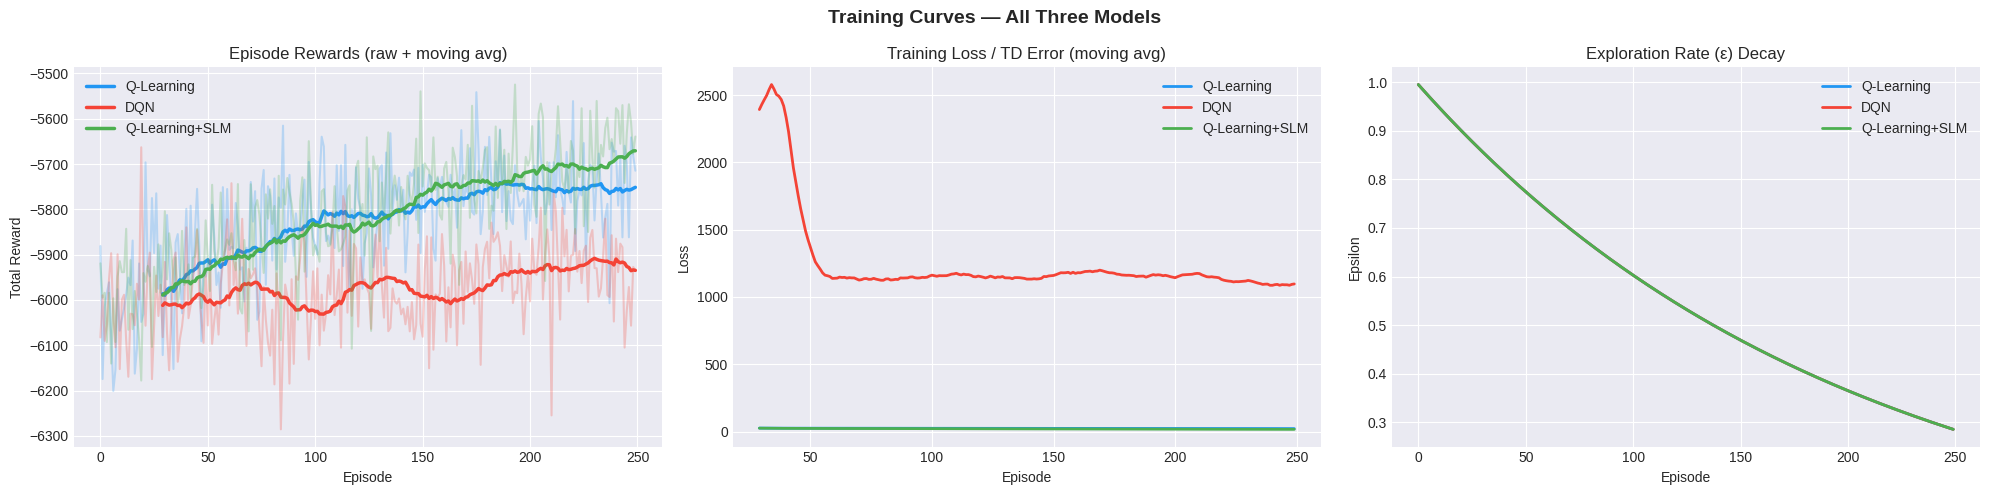

✓ Training curves plotted.


In [13]:
WINDOW = 30

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Training Curves — All Three Models', fontsize=14, fontweight='bold')

colours = {'Q-Learning': '#2196F3', 'DQN': '#F44336', 'Q-Learning+SLM': '#4CAF50'}
agents  = [
    ('Q-Learning',     q_agent.training_rewards),
    ('DQN',            dqn_agent.training_rewards),
    ('Q-Learning+SLM', qslm_agent.training_rewards),
]

# ── Panel A: individual curves
for name, rewards in agents:
    axes[0].plot(rewards, alpha=0.25, color=colours[name])
    axes[0].plot(pd.Series(rewards).rolling(WINDOW).mean(),
                 label=name, linewidth=2.5, color=colours[name])
axes[0].set_title('Episode Rewards (raw + moving avg)')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Total Reward')
axes[0].legend()

# ── Panel B: TD-loss curves
for name, agent in [('Q-Learning', q_agent),
                     ('DQN', dqn_agent),
                     ('Q-Learning+SLM', qslm_agent)]:
    axes[1].plot(pd.Series(agent.training_losses).rolling(WINDOW).mean(),
                 label=name, linewidth=2, color=colours[name])
axes[1].set_title('Training Loss / TD Error (moving avg)')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Loss')
axes[1].legend()

# ── Panel C: epsilon decay
for name, agent in [('Q-Learning', q_agent),
                     ('DQN', dqn_agent),
                     ('Q-Learning+SLM', qslm_agent)]:
    axes[2].plot(agent.epsilons, label=name, linewidth=2, color=colours[name])
axes[2].set_title('Exploration Rate (ε) Decay')
axes[2].set_xlabel('Episode'); axes[2].set_ylabel('Epsilon')
axes[2].legend()

plt.tight_layout()
plt.show()
print("✓ Training curves plotted.")

## Cell 13: Performance Comparison Charts

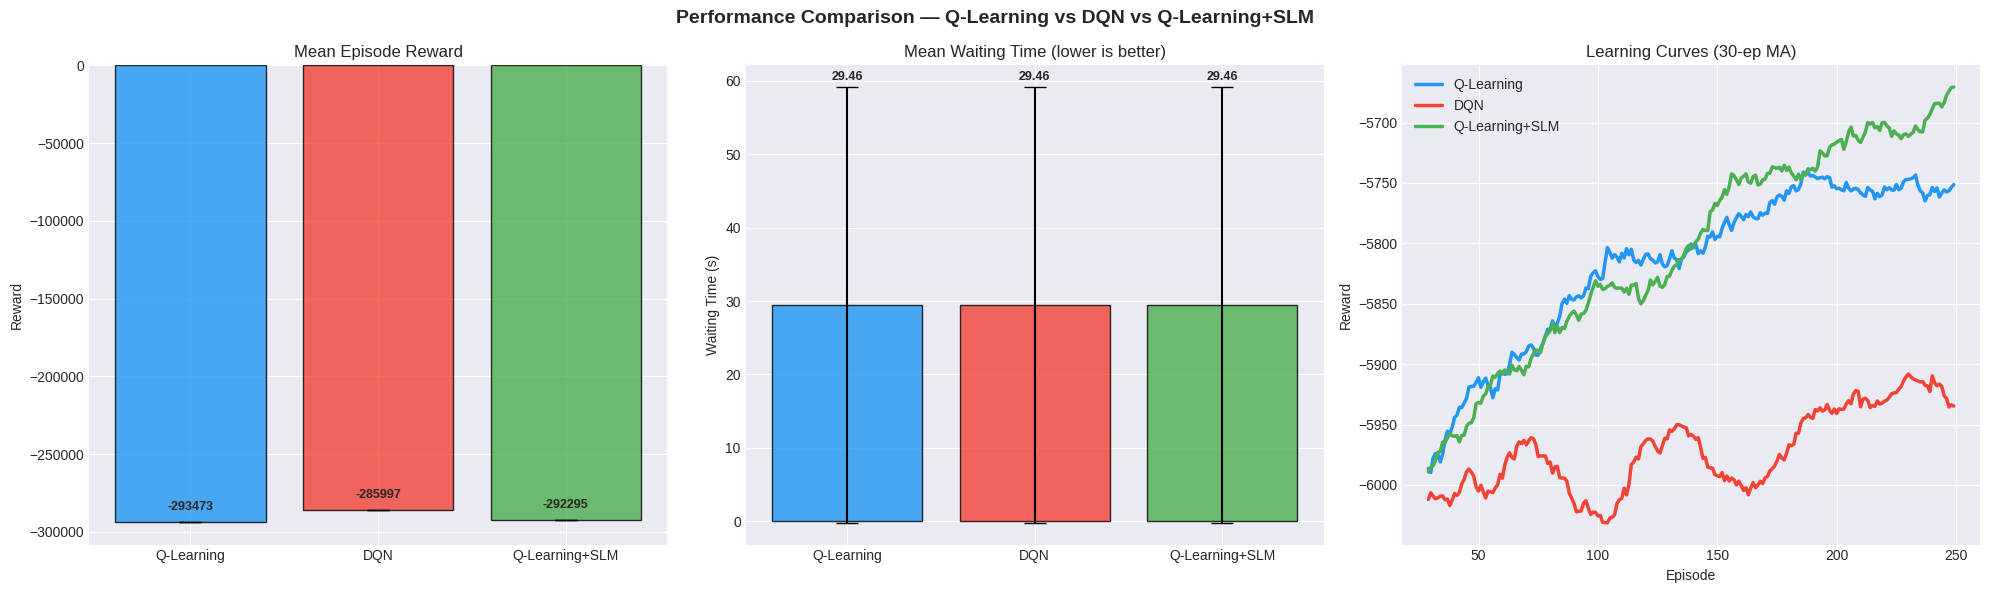

✓ Performance comparison charts done.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Performance Comparison — Q-Learning vs DQN vs Q-Learning+SLM',
             fontsize=14, fontweight='bold')

models      = ['Q-Learning', 'DQN', 'Q-Learning+SLM']
bar_colours = ['#2196F3', '#F44336', '#4CAF50']

mean_rewards= [q_metrics['mean_episode_reward'],
               dqn_metrics['mean_episode_reward'],
               qslm_metrics['mean_episode_reward']]
std_rewards = [q_metrics['std_episode_reward'],
               dqn_metrics['std_episode_reward'],
               qslm_metrics['std_episode_reward']]

mean_wait   = [q_metrics['mean_waiting_time'],
               dqn_metrics['mean_waiting_time'],
               qslm_metrics['mean_waiting_time']]
std_wait    = [q_metrics['std_waiting_time'],
               dqn_metrics['std_waiting_time'],
               qslm_metrics['std_waiting_time']]

# ── Bar 1: Mean episode reward
axes[0].bar(models, mean_rewards, yerr=std_rewards,
            color=bar_colours, edgecolor='black', alpha=0.8, capsize=8)
axes[0].set_title('Mean Episode Reward')
axes[0].set_ylabel('Reward')
for i, (m, s) in enumerate(zip(mean_rewards, std_rewards)):
    axes[0].text(i, m + s + abs(m)*0.02, f'{m:.0f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Bar 2: Mean waiting time
axes[1].bar(models, mean_wait, yerr=std_wait,
            color=bar_colours, edgecolor='black', alpha=0.8, capsize=8)
axes[1].set_title('Mean Waiting Time (lower is better)')
axes[1].set_ylabel('Waiting Time (s)')
for i, (m, s) in enumerate(zip(mean_wait, std_wait)):
    axes[1].text(i, m + s + abs(m)*0.02, f'{m:.2f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Panel 3: Smoothed learning curves overlaid
WINDOW = 30
for name, agent, c in zip(models,
                           [q_agent, dqn_agent, qslm_agent],
                           bar_colours):
    axes[2].plot(pd.Series(agent.training_rewards).rolling(WINDOW).mean(),
                 label=name, linewidth=2.5, color=c)
axes[2].set_title(f'Learning Curves ({WINDOW}-ep MA)')
axes[2].set_xlabel('Episode'); axes[2].set_ylabel('Reward')
axes[2].legend()

plt.tight_layout()
plt.show()
print("✓ Performance comparison charts done.")

## Cell 14: Action Distribution Analysis — All Three Agents

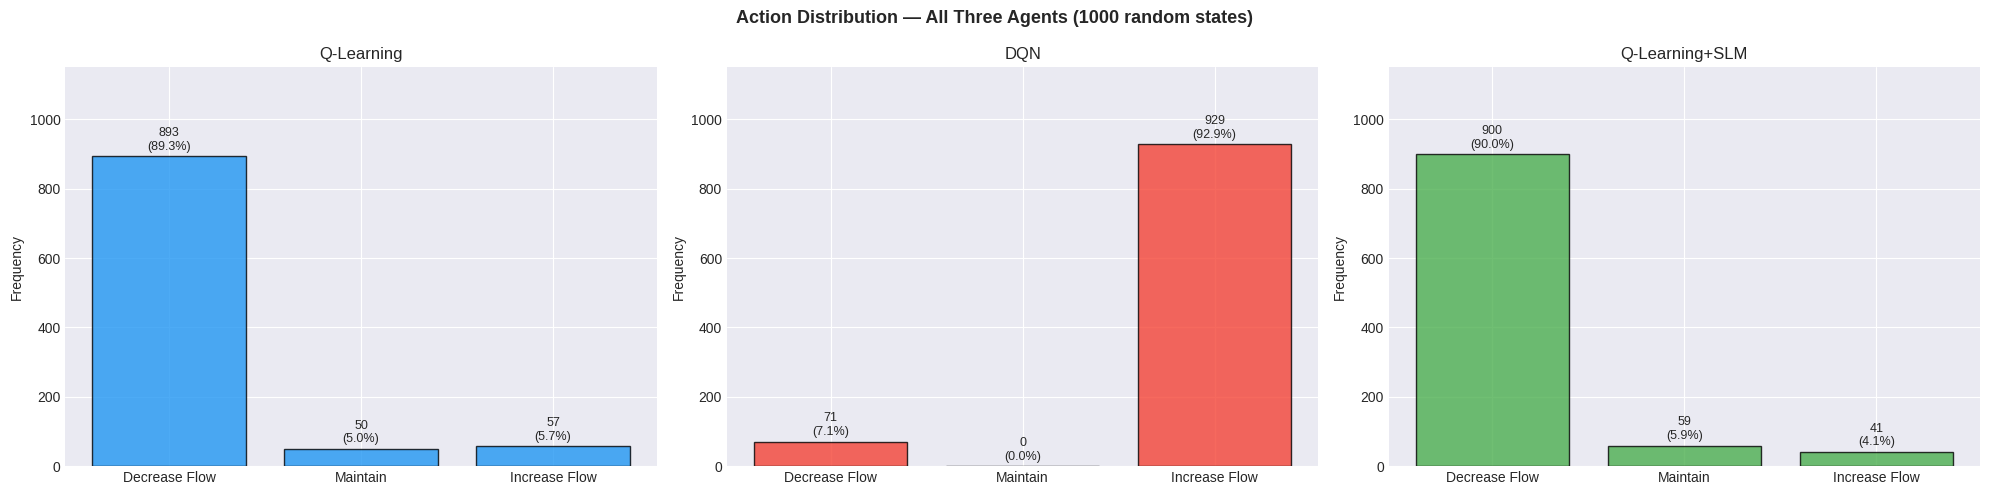


Action distribution summary:
  Q-Learning:
    Decrease Flow: 893 (89.3%)
    Maintain: 50 (5.0%)
    Increase Flow: 57 (5.7%)
  DQN:
    Decrease Flow: 71 (7.1%)
    Maintain: 0 (0.0%)
    Increase Flow: 929 (92.9%)
  Q-Learning+SLM:
    Decrease Flow: 900 (90.0%)
    Maintain: 59 (5.9%)
    Increase Flow: 41 (4.1%)


In [15]:
N_SAMPLES    = 1000
ACTION_NAMES = ['Decrease Flow', 'Maintain', 'Increase Flow']

q_actions, dqn_actions, qslm_actions = [], [], []

for _ in range(N_SAMPLES):
    state = env.sample_state()
    sv    = env._get_state_vector(state)

    q_actions.append(q_agent.get_action(state, training=False))
    dqn_actions.append(dqn_agent.get_action(sv, training=False))

    # For Q-SLM: temporarily point env to a random row so get_raw_features works
    env.current_idx = np.random.randint(len(env.data))
    a, _ = qslm_agent.get_action(state, env, training=False)
    qslm_actions.append(a)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Action Distribution — All Three Agents (1000 random states)',
             fontsize=13, fontweight='bold')

for ax, actions, name, c in zip(
        axes,
        [q_actions, dqn_actions, qslm_actions],
        ['Q-Learning', 'DQN', 'Q-Learning+SLM'],
        ['#2196F3', '#F44336', '#4CAF50']):
    counts = [actions.count(i) for i in range(3)]
    bars   = ax.bar(ACTION_NAMES, counts, color=c, edgecolor='black', alpha=0.8)
    ax.set_title(f'{name}')
    ax.set_ylabel('Frequency')
    ax.set_ylim(0, N_SAMPLES * 1.15)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 10,
                f'{cnt}\n({100*cnt/N_SAMPLES:.1f}%)',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nAction distribution summary:")
for name, actions in [('Q-Learning', q_actions),
                       ('DQN', dqn_actions),
                       ('Q-Learning+SLM', qslm_actions)]:
    print(f"  {name}:")
    for i, an in enumerate(ACTION_NAMES):
        c = actions.count(i)
        print(f"    {an}: {c} ({100*c/N_SAMPLES:.1f}%)")

## Cell 15: SLM Influence Visualisation

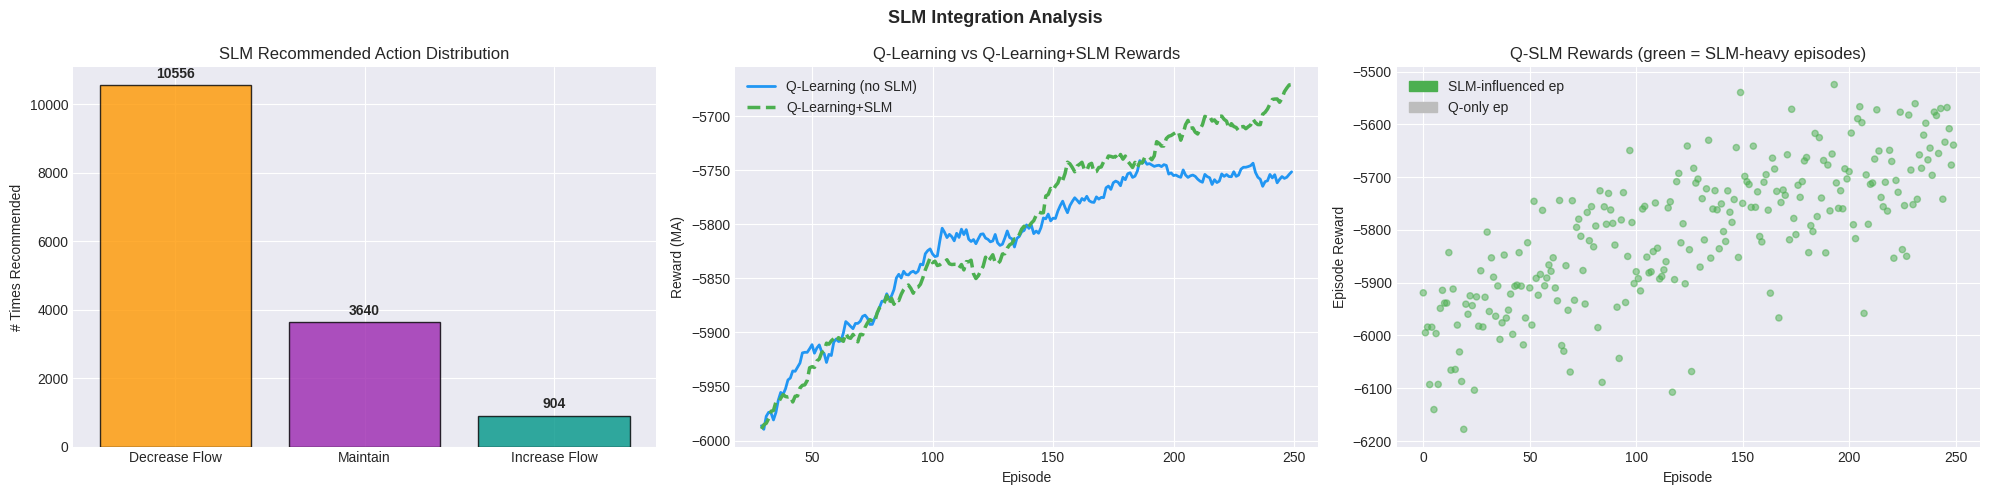

✓ SLM influence plots done.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('SLM Integration Analysis', fontsize=13, fontweight='bold')

# ── Panel A: SLM action distribution over training
slm_stats = qslm_agent.slm.get_stats()
if slm_stats['total_calls'] > 0:
    names  = list(slm_stats['action_dist'].keys())
    counts = list(slm_stats['action_dist'].values())
    axes[0].bar(names, counts, color=['#FF9800','#9C27B0','#009688'],
                edgecolor='black', alpha=0.8)
    axes[0].set_title('SLM Recommended Action Distribution')
    axes[0].set_ylabel('# Times Recommended')
    for i, c in enumerate(counts):
        axes[0].text(i, c + max(counts)*0.02, str(c),
                     ha='center', fontsize=10, fontweight='bold')

# ── Panel B: Q-Learning vs Q-Learning+SLM training rewards
WINDOW = 30
axes[1].plot(pd.Series(q_agent.training_rewards).rolling(WINDOW).mean(),
             label='Q-Learning (no SLM)', color='#2196F3', linewidth=2)
axes[1].plot(pd.Series(qslm_agent.training_rewards).rolling(WINDOW).mean(),
             label='Q-Learning+SLM', color='#4CAF50', linewidth=2.5,
             linestyle='--')
axes[1].set_title('Q-Learning vs Q-Learning+SLM Rewards')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Reward (MA)')
axes[1].legend()

# ── Panel C: SLM consultation frequency vs reward
ep_rewards = qslm_agent.training_rewards
slm_ep     = [1 if (i * MAX_STEPS % max(1, SLM_INTERVAL) == 0) else 0
              for i in range(len(ep_rewards))]
axes[2].scatter(range(len(ep_rewards)), ep_rewards,
                c=['#4CAF50' if s else '#BDBDBD' for s in slm_ep],
                alpha=0.5, s=20)
axes[2].set_title(f'Q-SLM Rewards (green = SLM-heavy episodes)')
axes[2].set_xlabel('Episode'); axes[2].set_ylabel('Episode Reward')
green_patch = mpatches.Patch(color='#4CAF50', label='SLM-influenced ep')
grey_patch  = mpatches.Patch(color='#BDBDBD', label='Q-only ep')
axes[2].legend(handles=[green_patch, grey_patch])

plt.tight_layout()
plt.show()
print("✓ SLM influence plots done.")

## Cell 16: Comprehensive Quantitative Summary

In [17]:
print("=" * 70)
print("COMPREHENSIVE THREE-MODEL COMPARISON")
print("=" * 70)

models_metrics = {
    'Q-Learning'     : q_metrics,
    'DQN'            : dqn_metrics,
    'Q-Learning+SLM' : qslm_metrics,
}

# ── 1. Reward
print("\n1. EPISODE REWARD (higher is better)")
for name, m in models_metrics.items():
    print(f"   {name:20s}: {m['mean_episode_reward']:10.2f} ± {m['std_episode_reward']:.2f}")

best_reward = max(models_metrics, key=lambda n: models_metrics[n]['mean_episode_reward'])
print(f"   → Best: {best_reward}")

# ── 2. Waiting time
print("\n2. WAITING TIME (lower is better)")
for name, m in models_metrics.items():
    print(f"   {name:20s}: {m['mean_waiting_time']:10.4f} ± {m['std_waiting_time']:.4f}")

best_wait = min(models_metrics, key=lambda n: models_metrics[n]['mean_waiting_time'])
print(f"   → Best: {best_wait}")

# ── 3. Stability
print("\n3. TRAINING STABILITY (last 100 episodes std — lower is more stable)")
for name, agent in [('Q-Learning', q_agent),
                     ('DQN', dqn_agent),
                     ('Q-Learning+SLM', qslm_agent)]:
    s = np.std(agent.training_rewards[-100:])
    print(f"   {name:20s}: {s:10.2f}")

# ── 4. Convergence speed
print("\n4. CONVERGENCE SPEED (episode where reward crosses 80% of final mean)")
for name, agent in [('Q-Learning', q_agent),
                     ('DQN', dqn_agent),
                     ('Q-Learning+SLM', qslm_agent)]:
    final_mean = np.mean(agent.training_rewards[-50:])
    thresh = 0.80 * final_mean
    ma = pd.Series(agent.training_rewards).rolling(20).mean()
    crossed = next((i for i, v in enumerate(ma) if v is not None
                    and not np.isnan(v) and (
                        (final_mean < 0 and v <= thresh) or
                        (final_mean >= 0 and v >= thresh)
                    )), None)
    ep_str = f"episode {crossed}" if crossed else "not converged"
    print(f"   {name:20s}: {ep_str}")

# ── 5. SLM overhead
print("\n5. SLM OVERHEAD (Q-Learning+SLM only)")
for k, v in qslm_agent.get_slm_stats().items():
    print(f"   {k}: {v}")

# ── 6. Complexity
print("\n6. MODEL COMPLEXITY")
print(f"   Q-Learning      : Q-table {len(q_agent.q_table):,} states × {env.n_actions} actions")
total_params = sum(p.numel() for p in dqn_agent.policy_net.parameters())
print(f"   DQN             : {total_params:,} NN parameters + {len(dqn_agent.replay_buffer):,} replay buffer")
print(f"   Q-Learning+SLM  : Q-table {len(qslm_agent.q_table):,} states + SLM every {qslm_agent.slm_interval} steps")

print("=" * 70)
print("SUMMARY")
print("=" * 70)
print("""
  Q-Learning         : Fast training, tabular, limited generalisation.
                       Works well in small discrete state spaces.

  DQN                : Function approximation, handles larger state spaces,
                       more stable due to replay buffer + target network.

  Q-Learning + SLM   : Q-Learning enriched with periodic domain-knowledge
                       consultations from the SLM every 10 steps.
                       SLM overrides high-confidence decisions; for lower
                       confidence it blends probabilities. The Q-table
                       gradually absorbs SLM guidance, combining speed of
                       tabular RL with the interpretability of language
                       model reasoning.
""")

COMPREHENSIVE THREE-MODEL COMPARISON

1. EPISODE REWARD (higher is better)
   Q-Learning          : -293473.06 ± 0.00
   DQN                 : -285997.42 ± 0.00
   Q-Learning+SLM      : -292295.06 ± 0.00
   → Best: DQN

2. WAITING TIME (lower is better)
   Q-Learning          :    29.4632 ± 29.6583
   DQN                 :    29.4632 ± 29.6583
   Q-Learning+SLM      :    29.4632 ± 29.6583
   → Best: Q-Learning

3. TRAINING STABILITY (last 100 episodes std — lower is more stable)
   Q-Learning          :      78.63
   DQN                 :      85.07
   Q-Learning+SLM      :      86.74

4. CONVERGENCE SPEED (episode where reward crosses 80% of final mean)
   Q-Learning          : episode 19
   DQN                 : episode 19
   Q-Learning+SLM      : episode 19

5. SLM OVERHEAD (Q-Learning+SLM only)
   total_slm_consultations: 15100
   slm_override_events: 2500
   override_rate_%: 16.6
   slm_action_distribution: {'Decrease Flow': 10556, 'Maintain': 3640, 'Increase Flow': 904}

6. MODEL

## Cell 17: Save All Models

In [18]:
import pickle, json as _json

# Q-Learning
with open('q_learning_model.pkl', 'wb') as f:
    pickle.dump({'q_table': dict(q_agent.q_table),
                 'training_rewards': q_agent.training_rewards,
                 'metrics': q_metrics}, f)
print("✓ q_learning_model.pkl saved")

# DQN
torch.save({'policy_net': dqn_agent.policy_net.state_dict(),
            'target_net': dqn_agent.target_net.state_dict(),
            'optimizer' : dqn_agent.optimizer.state_dict(),
            'training_rewards': dqn_agent.training_rewards,
            'metrics'   : dqn_metrics}, 'dqn_model.pth')
print("✓ dqn_model.pth saved")

# Q-Learning + SLM
with open('qslm_model.pkl', 'wb') as f:
    pickle.dump({'q_table': dict(qslm_agent.q_table),
                 'slm_stats': qslm_agent.get_slm_stats(),
                 'training_rewards': qslm_agent.training_rewards,
                 'metrics': qslm_metrics}, f)
print("✓ qslm_model.pkl saved")

# Comparison results
with open('comparison_results.pkl', 'wb') as f:
    pickle.dump({'q_learning': q_metrics,
                 'dqn'       : dqn_metrics,
                 'q_slm'     : qslm_metrics,
                 'comparison': cdf}, f)
print("✓ comparison_results.pkl saved")

✓ q_learning_model.pkl saved
✓ dqn_model.pth saved
✓ qslm_model.pkl saved
✓ comparison_results.pkl saved
